In [7]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [10]:
df=pd.read_csv(r"G:\vs code html\python start\Cleaned_Data.csv")

In [11]:
def tnpr(li):
    sum=0
    for i in li:
        sum+=i*0.1
    return sum

def sum_dur_hrs(li:list)->object:
    d,h,m,s=0,0,0,0
    for i in li:
        temp = i.split(":")
        h+=int(temp[0])
        m+=int(temp[1])
        s+=int(temp[2])
    if s>=60:
        m+=s//60
        s=s%60
    if m>=60:
        h+=m//60
        m=m%60
    if h>=24:
        d+=h//24
        h=h%24
    return f"{d} days,{h:02d}:{m:02d}:{s:02d}"

def rng_dm(li):
    maxi=max(li)
    a=maxi.split(":")
    re=[]
    h,m=0,0
    while h<int(a[0]):
        while (h<int(a[0]) and m<59) or (h==int(a[0]) and m<=int(a[1])):
            re.append(f"{h:02d}:{m:02d}:00")
            m+=10
        h+=1
        m=0
    return re

def stp_dm(a):
    re=a.split(":")
    h=re[0]
    m=re[1]
    return f"{h}:{int(m)+9:02d}:59"

def months(x):
    months={1:"January",
            2:"February",
            3:"March",
            4:"April",
            5:"May",
            6:"June",
            7:"July",
            8:"August",
            9:"September",
            10:"October",
            11:"November",
            12:"December"}
    if x in months.keys():
        return months[x]

In [12]:
# Graphs and Charts for Airlines
uair=df["Airline"].unique().tolist()

depart_airline={i:df[(df["Airline"]==i) & (df["Distance_km"]!=0)]["Flight_Number"].count() for i in uair}
canceled_airline={i:df[(df["Airline"]==i) & (df["Distance_km"]==0.0)]["Flight_Number"].count() for i in uair}

delayed_airline={i:int(df[(df["Airline"]==i) & (df["Delay_minutes"] > "00:01:00")] ["Flight_Number"].count()) for i in uair}
on_time_airline=df[df["Delay_minutes"]<="00:01:00"].groupby("Airline")["Flight_Number"].count().to_dict()

tic_airline=df[df["Distance_km"]!=0.0].groupby ("Airline")["Ticket_Price"].sum().to_dict()
extra_tic={i:tnpr(df[(df["Airline"]==i) & (df["Distance_km"]==0.0)]["Ticket_Price"].tolist()) for i in uair}
fuel_airlines=df.groupby("Airline")["Fuel_Cost"].sum().to_dict()

profit_airline={i:tic_airline[i]+extra_tic[i]-fuel_airlines[i] for i in uair}

pass_depart_airline=df[df["Distance_km"]!=0.0].groupby ("Airline")["Passenger_Count"].mean().to_dict()

pass_cancel_airline=df[df["Distance_km"]==0.0].groupby("Airline")["Passenger_Count"].mean().to_dict()

flight_toff_count={m:[[q,list(n.values()).count(q)]for q in set(n.values())]
                    for m,n in {i:df[(df["Airline"]==i) &
                                    (df["Distance_km"]!=0.0)]
                                    ["Flight_Number"].value_counts().to_dict()
                    for i in df["Airline"].unique().tolist()}.items()}

flight_canc_count={m:[[q,list(n.values()).count(q)]for q in set(n.values())]
                    for m,n in {i:df[(df["Airline"]==i) &
                                    (df["Distance_km"]==0.0)]
                                    ["Flight_Number"].value_counts().to_dict()
                    for i in df["Airline"].unique().tolist()}.items()}

In [13]:
# For Aircraft Type:
canceled_airType={i:df[(df["Distance_km"]==0.0) &
                    (df["Airline"]==i)].groupby("Aircraft_Type")["Flight_Number"].count().to_dict()
                    for i in df.groupby("Airline")["Aircraft_Type"].unique().to_dict()}

canc_airtype=(pd.DataFrame.from_dict(canceled_airType,orient="index").stack().reset_index())

canc_airtype.columns=["Airline","Aircraft_Type","Cancelled_count"]


departed_airType={i:df[(df["Distance_km"]!=0.0) &
                        (df["Airline"]==i)].groupby("Aircraft_Type")["Flight_Number"].count().to_dict()
                        for i in df.groupby("Airline")["Aircraft_Type"].unique().to_dict()}

dept_airtype=(pd.DataFrame.from_dict(departed_airType,orient="index").stack().reset_index())

dept_airtype.columns=["Airline","Aircraft_Type","Departed_count"]
canc_dept_airtype=pd.merge(canc_airtype,dept_airtype,on=["Airline","Aircraft_Type"],how="outer").fillna(0)

Org_airtype=df.groupby(["Airline","Aircraft_Type","Origin"],as_index=False).agg(Flight_count=("Flight_Number","count"))
Dest_airtype=df.groupby(["Airline","Aircraft_Type","Destination"],as_index=False).agg(Flight_count=("Flight_Number","count"))

tft={i:{k:sum_dur_hrs(df[(df["Distance_km"]!=0.0) & 
                        (df["Airline"]==i) & 
                        (df["Aircraft_Type"]==k)]["Duration_hours"].tolist()) 
        for k in j 
    } for i, j in df.groupby("Airline")["Aircraft_Type"].unique().to_dict().items()}

total_flight_time=(pd.DataFrame.from_dict(tft,orient="index").stack().reset_index())
total_flight_time.columns=["Airline","Aircraft_Type","Total_flight_time"]

pass_dept_airtype_count=df[df["Distance_km"]!=0.0].groupby(["Airline","Aircraft_Type"],as_index=False).agg(passenger_count=("Passenger_Count","sum"),average_passenger=("Passenger_Count","mean"))
pass_canc_airtype_count=df[df["Distance_km"]==0.0].groupby(["Airline","Aircraft_Type"],as_index=False).agg(passenger_count=("Passenger_Count","sum"),average_passenger=("Passenger_Count","mean"))

ttp={i:df[(df["Airline"]==i) & (df["Distance_km"]!=0.0)].groupby("Aircraft_Type")["Ticket_Price"].sum().to_dict() for i in df.groupby("Airline")["Aircraft_Type"].unique().to_dict()}
cttp={i:df[(df["Airline"]==i) & (df["Distance_km"]==0.0)].groupby("Aircraft_Type")["Ticket_Price"].sum().to_dict() for i in df.groupby("Airline")["Aircraft_Type"].unique().to_dict()}
tfc={i:df[(df["Airline"]==i) & (df["Distance_km"]!=0.0)].groupby("Aircraft_Type")["Fuel_Cost"].sum().to_dict() for i in df.groupby("Airline")["Aircraft_Type"].unique().to_dict()}
tp={i:{j:round((ttp[i][j]+(0.1*cttp[i][j]))-tfc[i][j],2) for j in ttp[i]} for i in ttp}
airtype_profit=pd.DataFrame.from_dict(tp,orient="index").stack().reset_index()
airtype_profit.columns=["Airline","Aircraft_Type","Profit"]

airtype_delay_count_depart={i:{a:{(r,stp_dm(r)):int(df[(df["Airline"]==i) & 
                                                        (df["Distance_km"]!=0.0) & 
                                                        (df["Aircraft_Type"]==a) & 
                                                        (df["Delay_minutes"]>=r) & 
                                                        (df["Delay_minutes"]<=stp_dm(r))]["Flight_Number"].count()) for r in de 
                                    } for a,de in {k:rng_dm(df[(df["Airline"]==i) & 
                                                                (df["Aircraft_Type"]==k)]["Delay_minutes"].unique().tolist()) for k in j 
                                                  }.items() 
                            } for i,j in df.groupby("Airline")["Aircraft_Type"].unique().to_dict().items()}

airtype_delay_count_canc={i:{a:{(r,stp_dm(r)):int(df[(df["Airline"]==i) & 
                                                       (df["Distance_km"]==0.0) & 
                                                       (df["Aircraft_Type"]==a) & 
                                                       (df["Delay_minutes"]>=r) & 
                                                       (df["Delay_minutes"]<=stp_dm(r))]["Flight_Number"].count()) for r in de 
                                   } for a,de in {k:rng_dm(df[(df["Airline"]==i) & 
                                                               (df["Aircraft_Type"]==k)]["Delay_minutes"].unique().tolist()) for k in j 
                                                 }.items() 
                           } for i,j in df.groupby("Airline")["Aircraft_Type"].unique().to_dict().items()}

In [14]:
# about Date

In [15]:
df["Date"]=pd.to_datetime(df["Date"],format="%Y-%m-%d")
dfd={months(i):
                {k:
                int(df[(df["Distance_km"]!=0.0) &
                    (df["Date"].dt.month==i) &
                    (df["Date"].dt.day==k)]["Flight_Number"].count())
                for k in j
               } for i,j in {i:
               set(df[(df["Date"].dt.month==i)]
                    ["Date"].dt.day.unique().tolist())
                    for i in set(df["Date"].dt.month.unique().tolist())
                    }.items()
        }
Daily_flight_deprt_count=pd.DataFrame.from_dict(dfd,orient="index").fillna(0).astype("int")

dcd={months(i):
                {k:
                int(df[(df["Distance_km"]==0.0) &
                    (df["Date"].dt.month==i) &
                    (df["Date"].dt.day==k)]["Flight_Number"].count())
                    for k in j
               } for i,j in {i:
               set(df[(df["Date"].dt.month==i)]
                    ["Date"].dt.day.unique().tolist())
                    for i in set(df["Date"].dt.month.unique().tolist())
                    }.items()
        }
Daily_flight_cancl_count=pd.DataFrame.from_dict(dcd,orient="index").fillna(0).astype("int")

In [16]:
#Daily_flight_cancl_count

In [17]:
#Daily passsenger count
apc={i:{months(m):{d:int(df[(df["Airline"]==i) &
                        (df["Date"].dt.month==m) &
                        (df["Date"].dt.day==d) &
                        (df["Distance_km"]!=0.0)]["Passenger_Count"].sum()) for d in ds  
                        } for m,ds in {k:
                                    set(df[df["Date"].dt.month==k]["Date"].dt.day.unique().tolist())
                                    for k in j
                                    }.items()
                    } for i,j in {i:
                    set(df["Date"].dt.month.unique().tolist()) for i in df["Airline"].unique().tolist()
                    }.items()
            }
rows=[]
for i,j in apc.items():
    for l,k in j.items():
        for m,n in k.items():
            rows.append({"Airline":i,
                "Months":l,
                "Days":m,
                "Passenger_Count":n})
flten_df=pd.DataFrame(rows)
Airline_daily_pass_count=(flten_df.pivot_table(index=["Airline","Months"],
                                                columns="Days",
                                                values="Passenger_Count",
                                                fill_value=0)
                                                .reset_index())

Airline_daily_pass_count["Months"]=Airline_daily_pass_count["Months"].apply(lambda x:months(x))

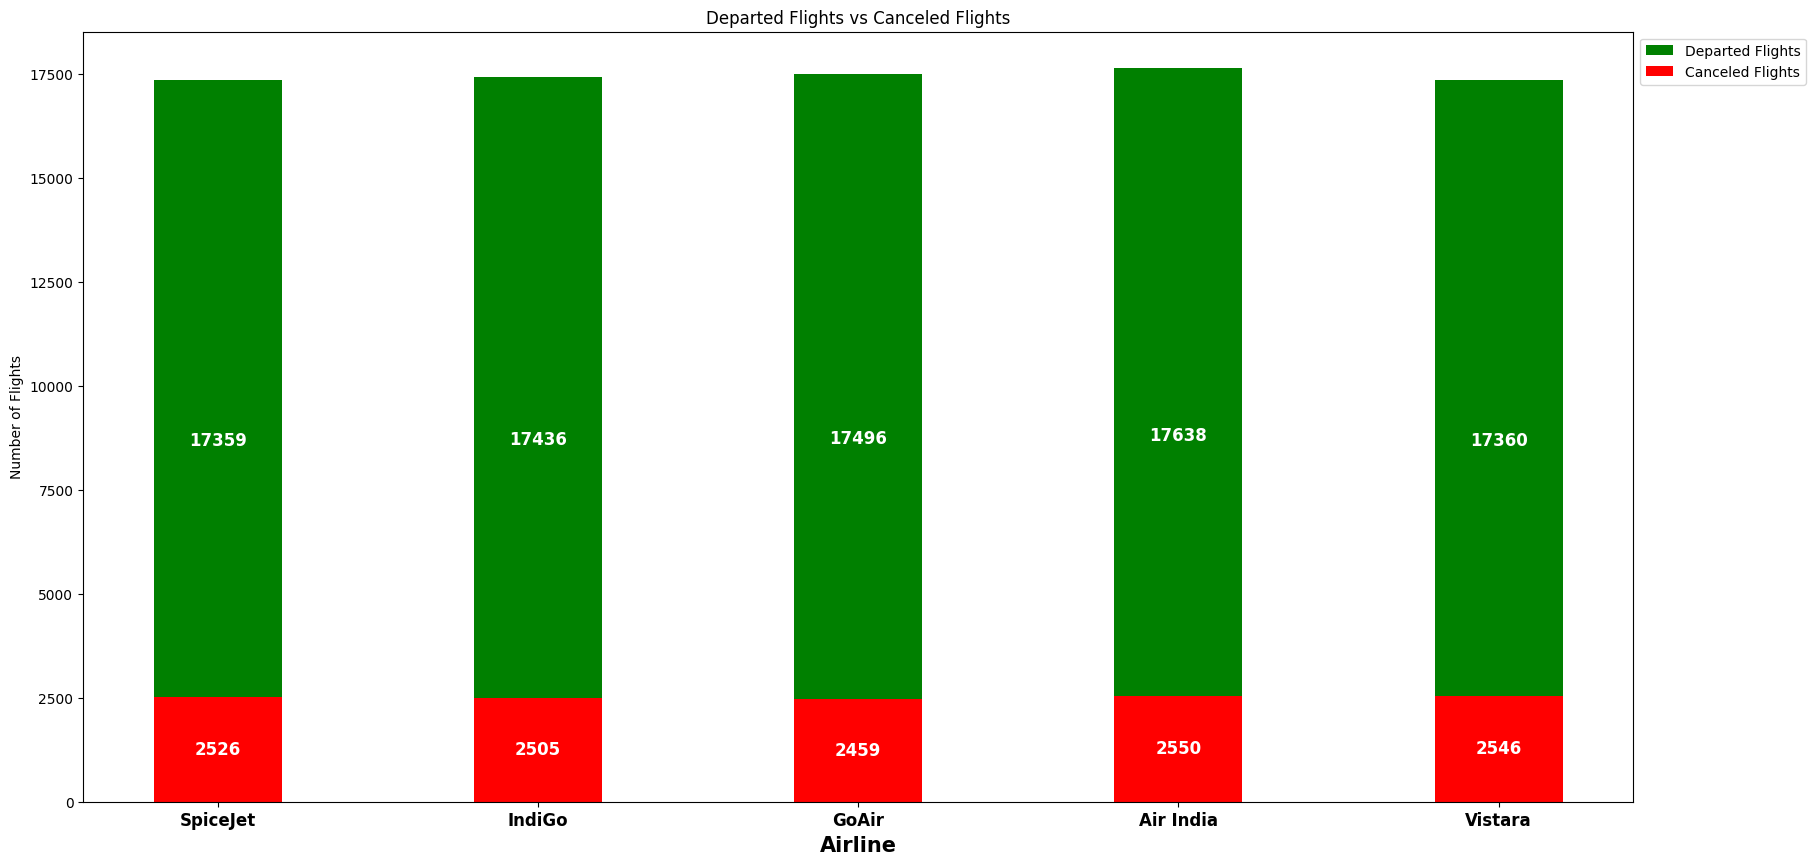

In [18]:
plt.figure(figsize=(20,10))
b1=plt.bar(depart_airline.keys(),depart_airline.values(),0.4,color="green",label="Departed Flights")
b2=plt.bar(canceled_airline.keys(),canceled_airline.values(),0.4,color="red",label="Canceled Flights")
#plt.grid(True)
plt.bar_label(b1,label_type="center",color="white",fontsize=12,fontweight="bold")
plt.bar_label(b2,label_type="center",color="white",fontsize=12,fontweight="bold")

plt.xlabel("Airline",fontsize=15,fontweight="bold")
plt.ylabel("Number of Flights")
plt.title("Departed Flights vs Canceled Flights")
plt.xticks(fontsize=12,fontweight="bold")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

In [19]:
uair=df["Airline"].unique().tolist()
depart_airline={i:df[(df["Airline"]==i) & (df["Distance_km"]!=0)]["Flight_Number"].count() for i in uair}
canceled_airline={i:df[(df["Airline"]==i) & (df["Distance_km"]==0.0)]["Flight_Number"].count() for i in uair}
data={i:[j,depart_airline[i]]for i,j in canceled_airline.items()}
a=list(data.keys())

g1=[j[0] for j in data.values()]
g2=[j[1] for j in data.values()]

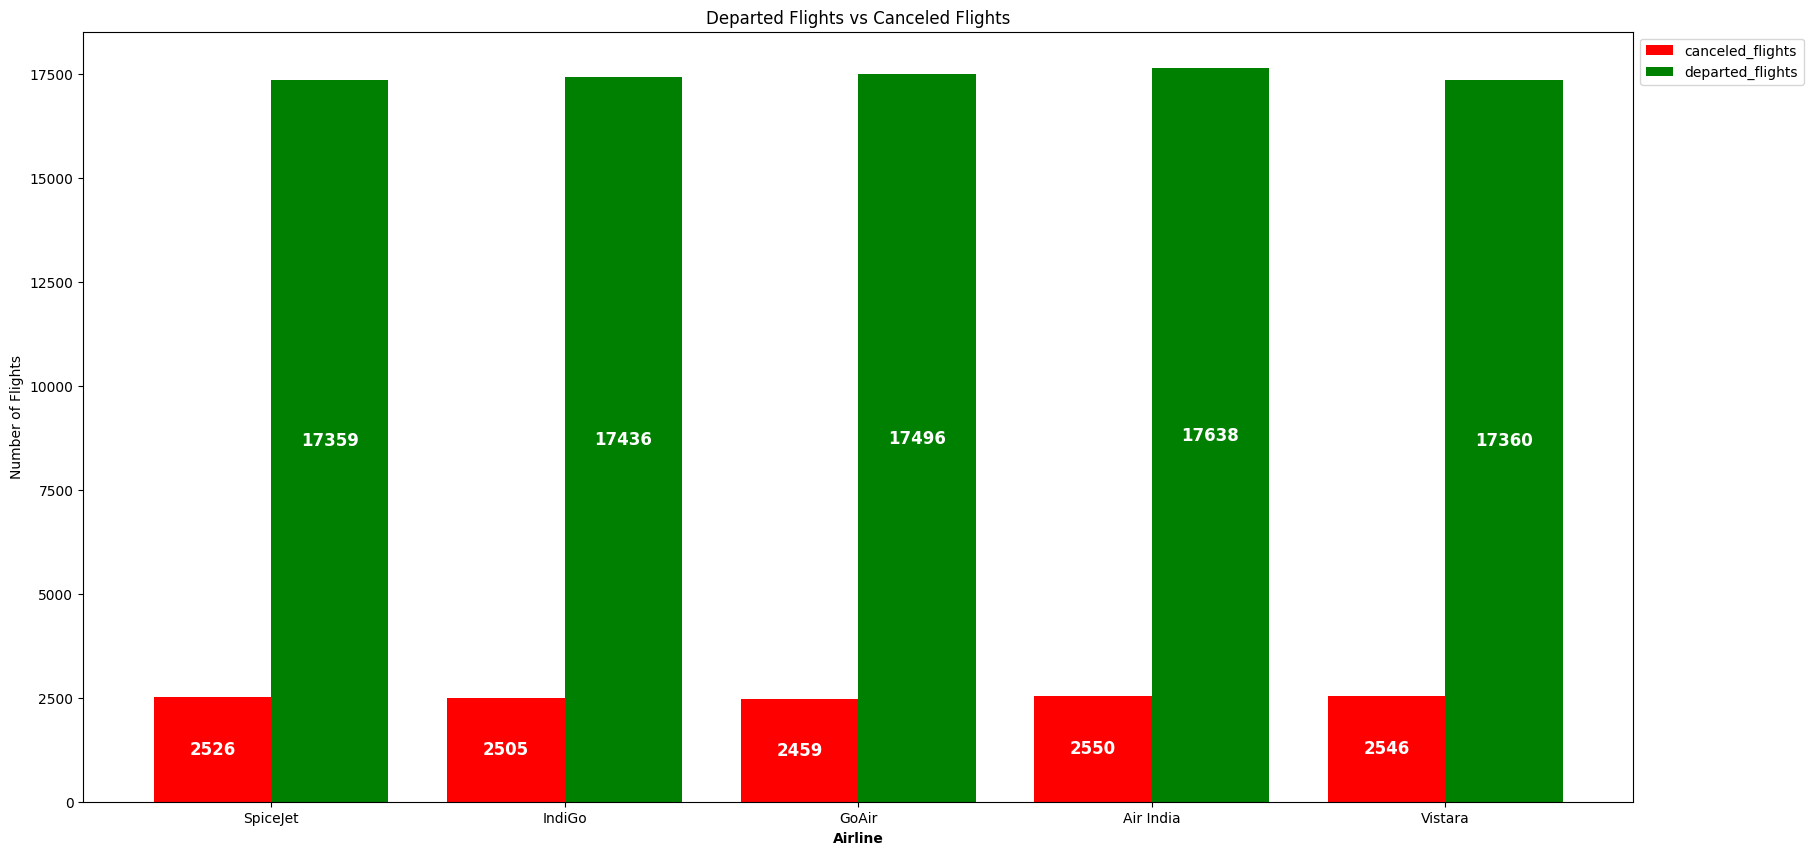

In [20]:
plt.figure(figsize=(20,10))
data={i:[j,depart_airline[i]]for i,j in canceled_airline.items()}
a=list(data.keys())
g1=[j[0] for j in data.values()]
g2=[j[1] for j in data.values()]
x=np.arange(len(a))
d1=plt.bar(x-0.2,g1,0.4,color="red",label="canceled_flights")
d2=plt.bar(x+0.2,g2,0.4,color="green",label="departed_flights")

plt.bar_label(d1,label_type="center",color="white",fontsize=12,fontweight="bold")
plt.bar_label(d2,label_type="center",color="white",fontsize=12,fontweight="bold")

plt.xlabel("Airline",fontsize=10,fontweight="bold")
plt.ylabel("Number of Flights")
plt.title("Departed Flights vs Canceled Flights")
plt.xticks(x,a)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

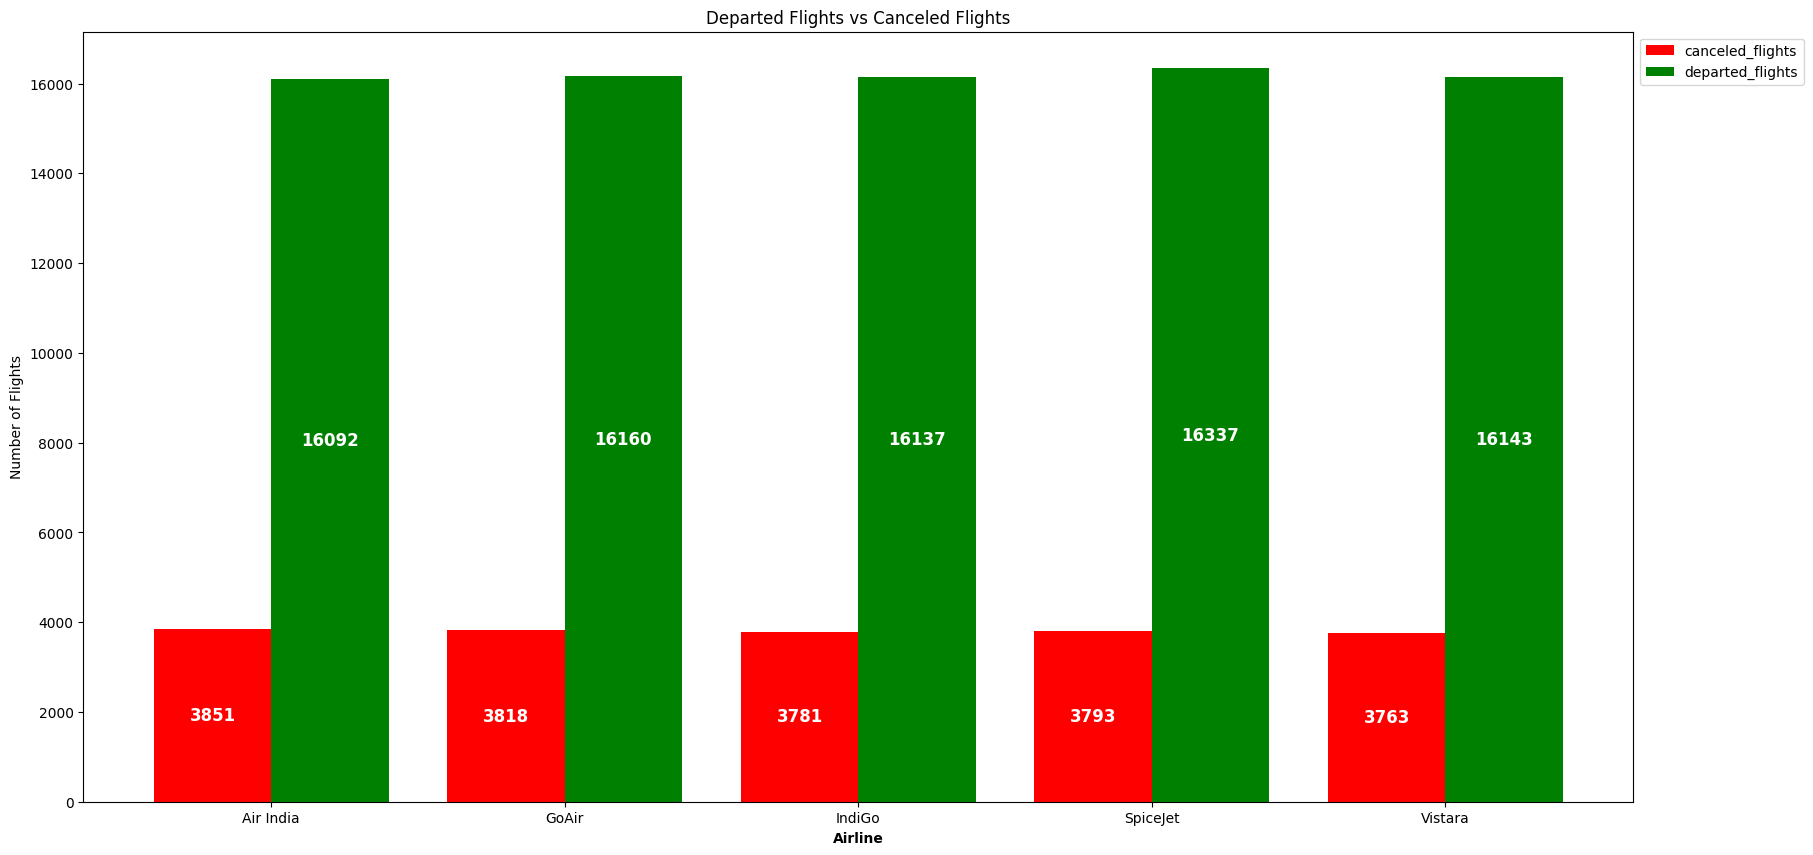

In [21]:
plt.figure(figsize=(20,10))
a=list(on_time_airline.keys())
x=np.arange(len(a))
g1=list(on_time_airline.values())
g2=list(delayed_airline.values())
d1=plt.bar(x-0.2,g1,0.4,color="red",label="canceled_flights")
d2=plt.bar(x+0.2,g2,0.4,color="green",label="departed_flights")

plt.bar_label(d1,label_type="center",color="white",fontsize=12,fontweight="bold")
plt.bar_label(d2,label_type="center",color="white",fontsize=12,fontweight="bold")

plt.xlabel("Airline",fontsize=10,fontweight="bold")
plt.ylabel("Number of Flights")
plt.title("Departed Flights vs Canceled Flights")
plt.xticks(x,a)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

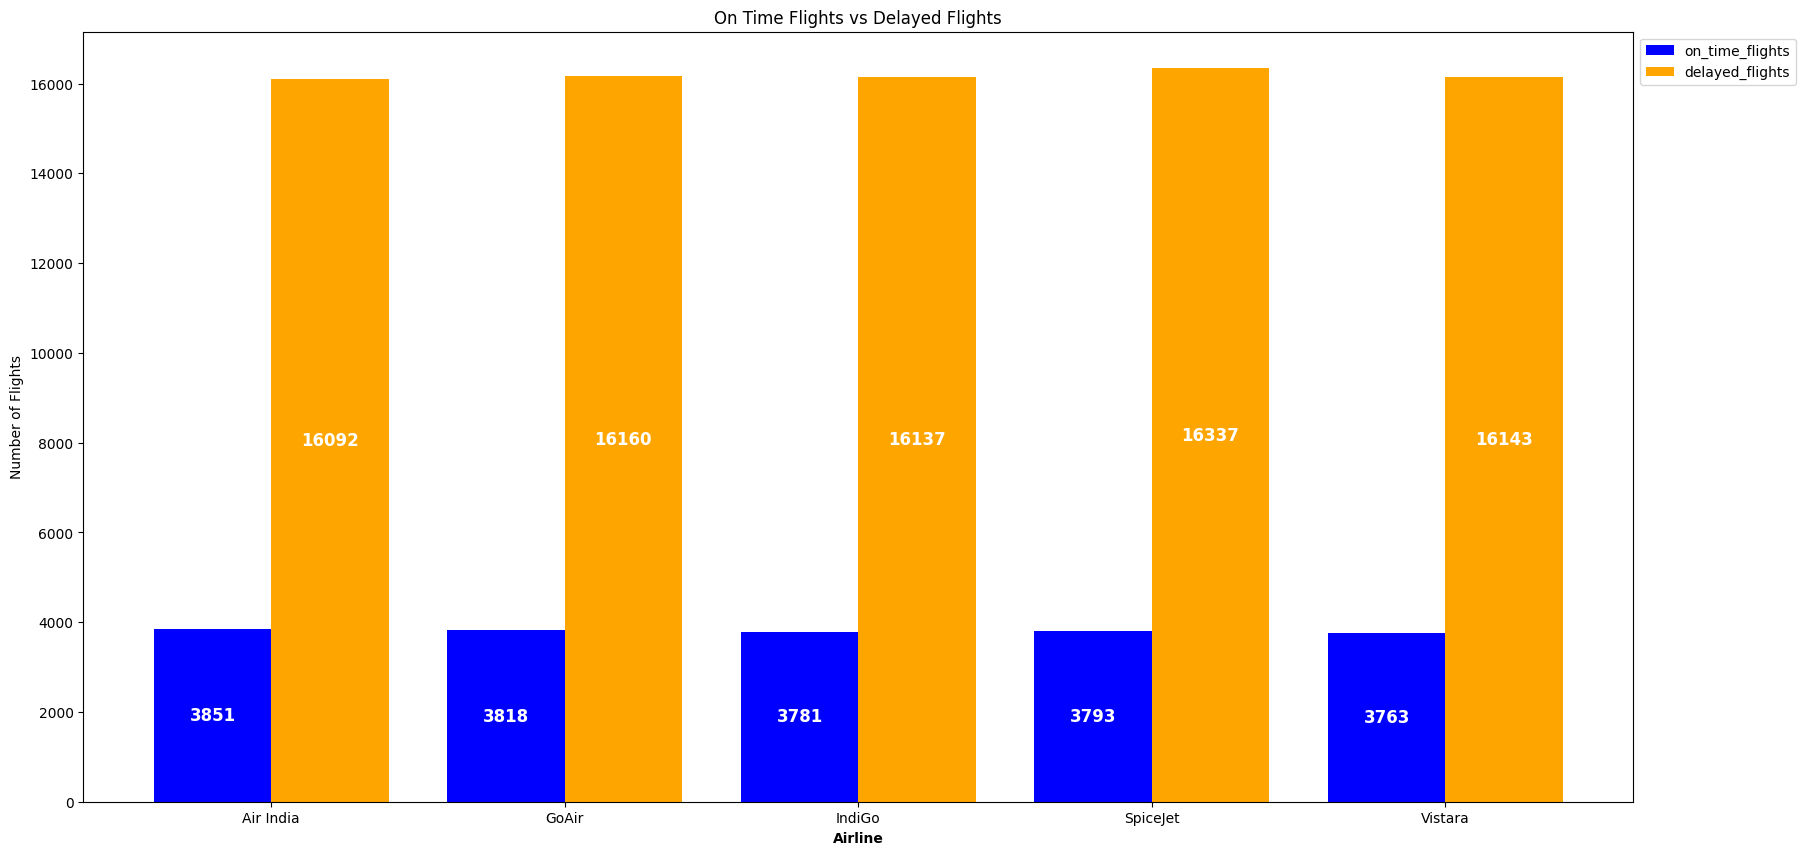

In [22]:
#try new colors
plt.figure(figsize=(20,10))
a=list(on_time_airline.keys())
x=np.arange(len(a))
g1=list(on_time_airline.values())
g2=list(delayed_airline.values())
d1=plt.bar(x-0.2,g1,0.4,color="blue",label="on_time_flights")
d2=plt.bar(x+0.2,g2,0.4,color="orange",label="delayed_flights")

plt.bar_label(d1,label_type="center",color="white",fontsize=12,fontweight="bold")
plt.bar_label(d2,label_type="center",color="white",fontsize=12,fontweight="bold")

plt.xlabel("Airline",fontsize=10,fontweight="bold")
plt.ylabel("Number of Flights")
plt.title("On Time Flights vs Delayed Flights")
plt.xticks(x,a)
plt.legend(bbox_to_anchor=(1,1))
plt.show()

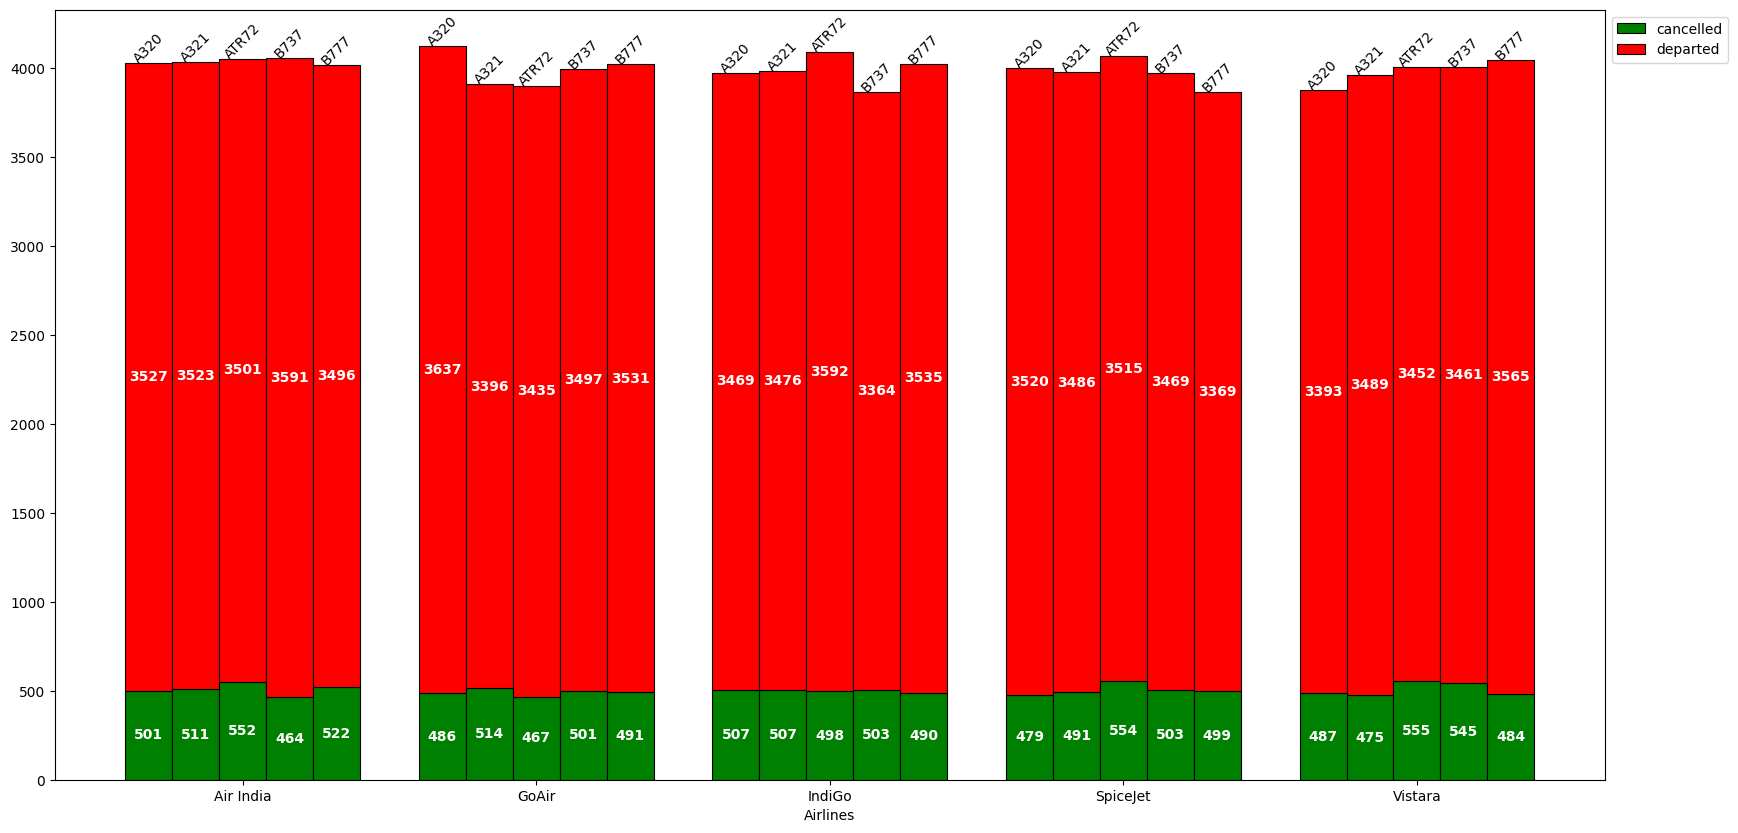

In [23]:
# Data Extraction (Based on the logic in the image)
airline = canc_dept_airtype["Airline"].unique()
aircrafts = canc_dept_airtype["Aircraft_Type"].unique()
x = np.arange(len(airline))
width = 0.8 / len(aircrafts)
fig, ax = plt.subplots(figsize=(20, 10))

# Plotting Loop
for ind, at in enumerate(aircrafts):
    sub = canc_dept_airtype[canc_dept_airtype["Aircraft_Type"] == at]
    y_canc = [sub[sub["Airline"] == i]["Cancelled_count"].sum() for i in airline]
    y_dept = [sub[sub["Airline"] == i]["Departed_count"].sum() for i in airline]

    xpos = x - 0.4 + width/2 + ind * width
    
    # Create the stacked bars (Cancelled on bottom, Departed on top)
    b1 = ax.bar(xpos, y_canc, width, color="green", label="cancelled" if ind == 0 else None, edgecolor="black", linewidth=0.8)
    b2 = ax.bar(xpos, y_dept, width, bottom=y_canc, color="red", label="departed" if ind == 0 else None, edgecolor="black", linewidth=0.8)
    
    # Add labels inside the bars
    ax.bar_label(b1, label_type="center", color="white", fontweight="bold")
    ax.bar_label(b2, label_type="center", color="white", fontweight="bold")
    
    # Add text labels above the bars
    for bi, bar in enumerate(b2):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + b1[bi].get_height()+1,
            at,
            ha="center",
            rotation=45
        )

# Chart Formatting
ax.set_xticks(x)
ax.set_xticklabels(airline)
plt.xlabel("Airlines")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

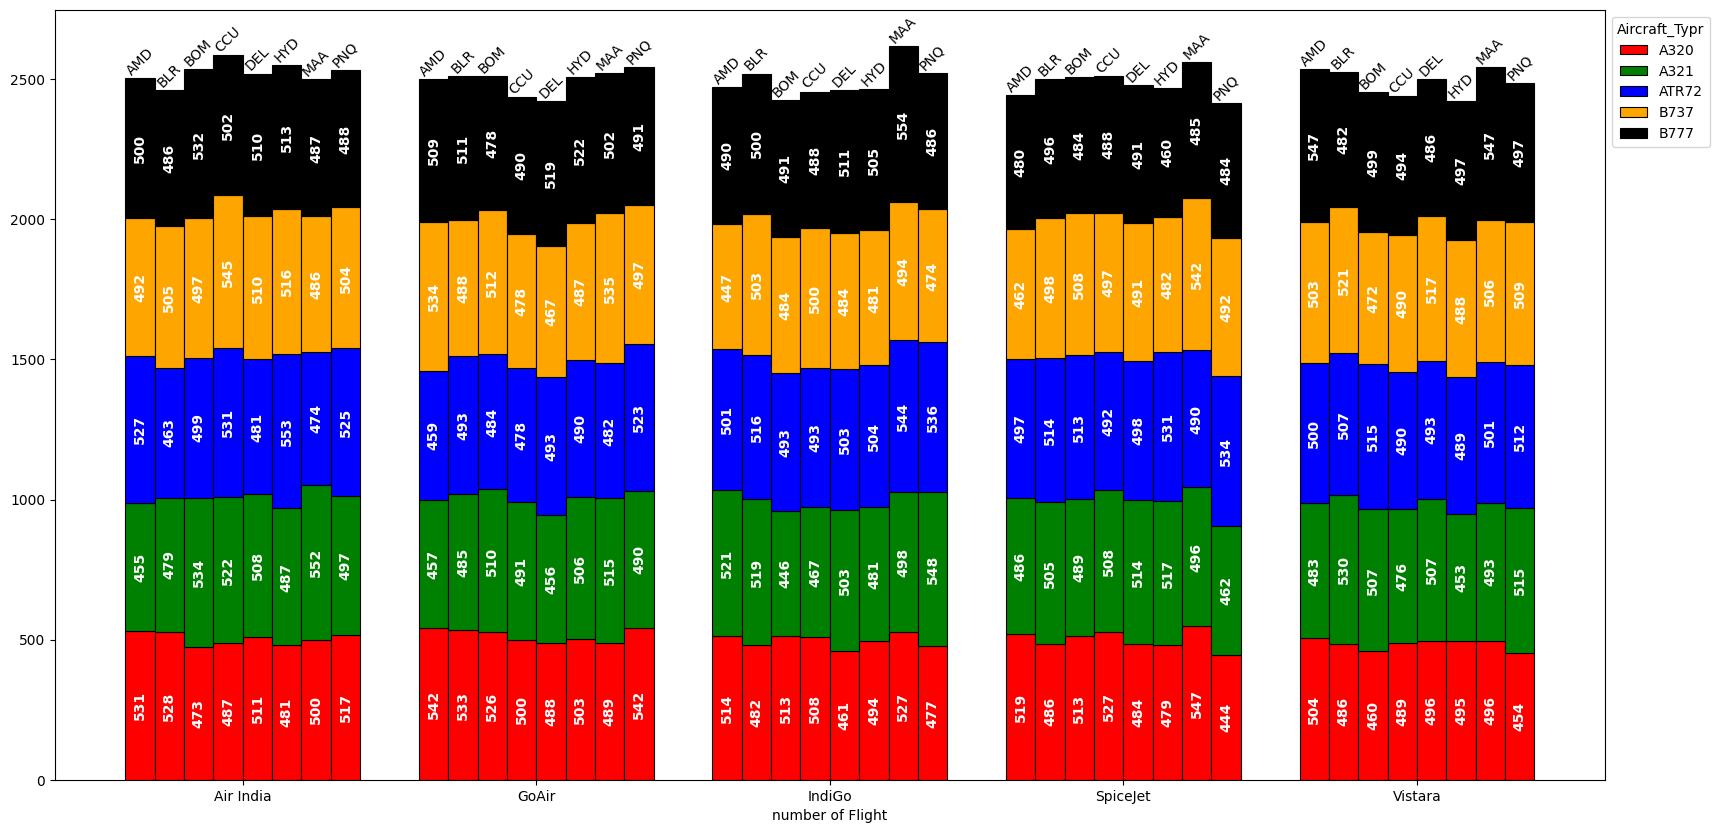

In [24]:
air=Org_airtype["Airline"].unique()
aircrafts=Org_airtype["Aircraft_Type"].unique()
origin=Org_airtype["Origin"].unique()

fig,ax=plt.subplots(figsize=(20,10))
x=np.arange(len(air))                  #ax=axis 
width=0.8
color=["red","green","blue","orange","black"]
for i,airline in enumerate(air):                 # airline iterate
    sub=Org_airtype[Org_airtype["Airline"]==airline] #
    piv_sub=sub.pivot_table(index="Origin",columns="Aircraft_Type",values="Flight_count",fill_value=0).astype("int")
    bar_width=width/len(origin)

    start=x[i]-width/2        
    for j,origins in enumerate(origin):
        xpo=start+j*bar_width
        bottom=0
        for k,at in enumerate(aircrafts):
            val=piv_sub.loc[origins,at]
            b1=ax.bar(xpo,val,bar_width,bottom=bottom,color=color[k],label=at if (i==0 and j==0) else None,edgecolor="black",linewidth=0.8)
            bottom+=val
            ax.bar_label(b1,label_type="center",color="white",fontweight="bold",rotation=90)
        ax.text(xpo,bottom+1,origins,ha="center",va="bottom",rotation=45)


ax.set_xticks(x-0.05)
ax.set_xticklabels(air)
plt.xlabel("number of Flight")
plt.legend(title="Aircraft_Typr",bbox_to_anchor=(1, 1))
plt.show()

In [25]:
# total_flight_time

In [26]:
def plt_time(a):
    ti=a.split(",")[1].split(":") 
    dy=a.split(",")[0].split()[0]
    ds=round((int(ti[0])*3600 +int(ti[1])*60+int(ti[2]))/86400,2)
    return int(dy) + ds 

total_flight_time["plt_time"]=total_flight_time["Total_flight_time"].apply(plt_time) 
#adding new column(plt_time) in totalflight time 
ploting_df=total_flight_time.pivot_table(
    index="Airline",
    columns="Aircraft_Type",
    values="plt_time",
    fill_value=0
)
anonot_df=total_flight_time.pivot(
    index="Airline",
    columns="Aircraft_Type",
    values="Total_flight_time"
)


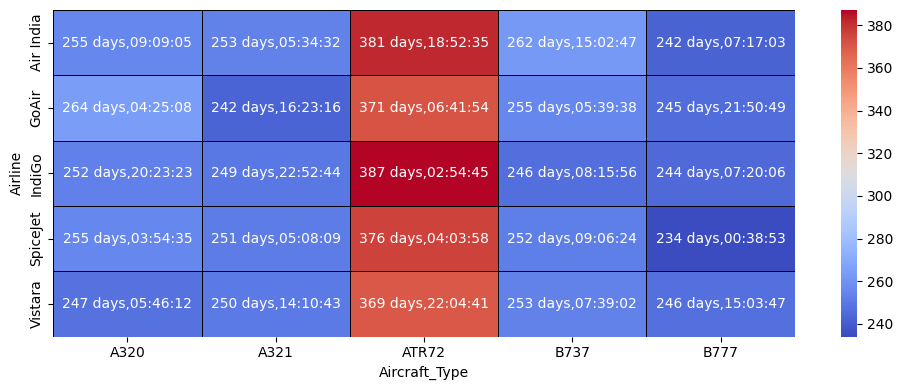

In [27]:
plt.figure(figsize=(10,4))
sns.heatmap(ploting_df,annot=anonot_df.values,fmt="",cmap="coolwarm",linecolor="black",linewidth=0.5)
plt.tight_layout()
plt.show()

In [28]:
ADPC=df[df["Distance_km"]!=0.0].assign(month=df["Date"].dt.month,
                                       day=df["Date"].dt.day).groupby(["Airline","month","day"],
                                                                      as_index=False).agg(Passenger_count=("Passenger_Count","sum")).pivot_table(index=["Airline","month"],
                                                                                                                                                 columns="day",
                                                                                                                                                 values="Passenger_count",
                                                                                                                                                 fill_value=0).astype("int").reset_index()

ADPC["month"]=ADPC["month"].apply(lambda x:months(x))
#ADPC

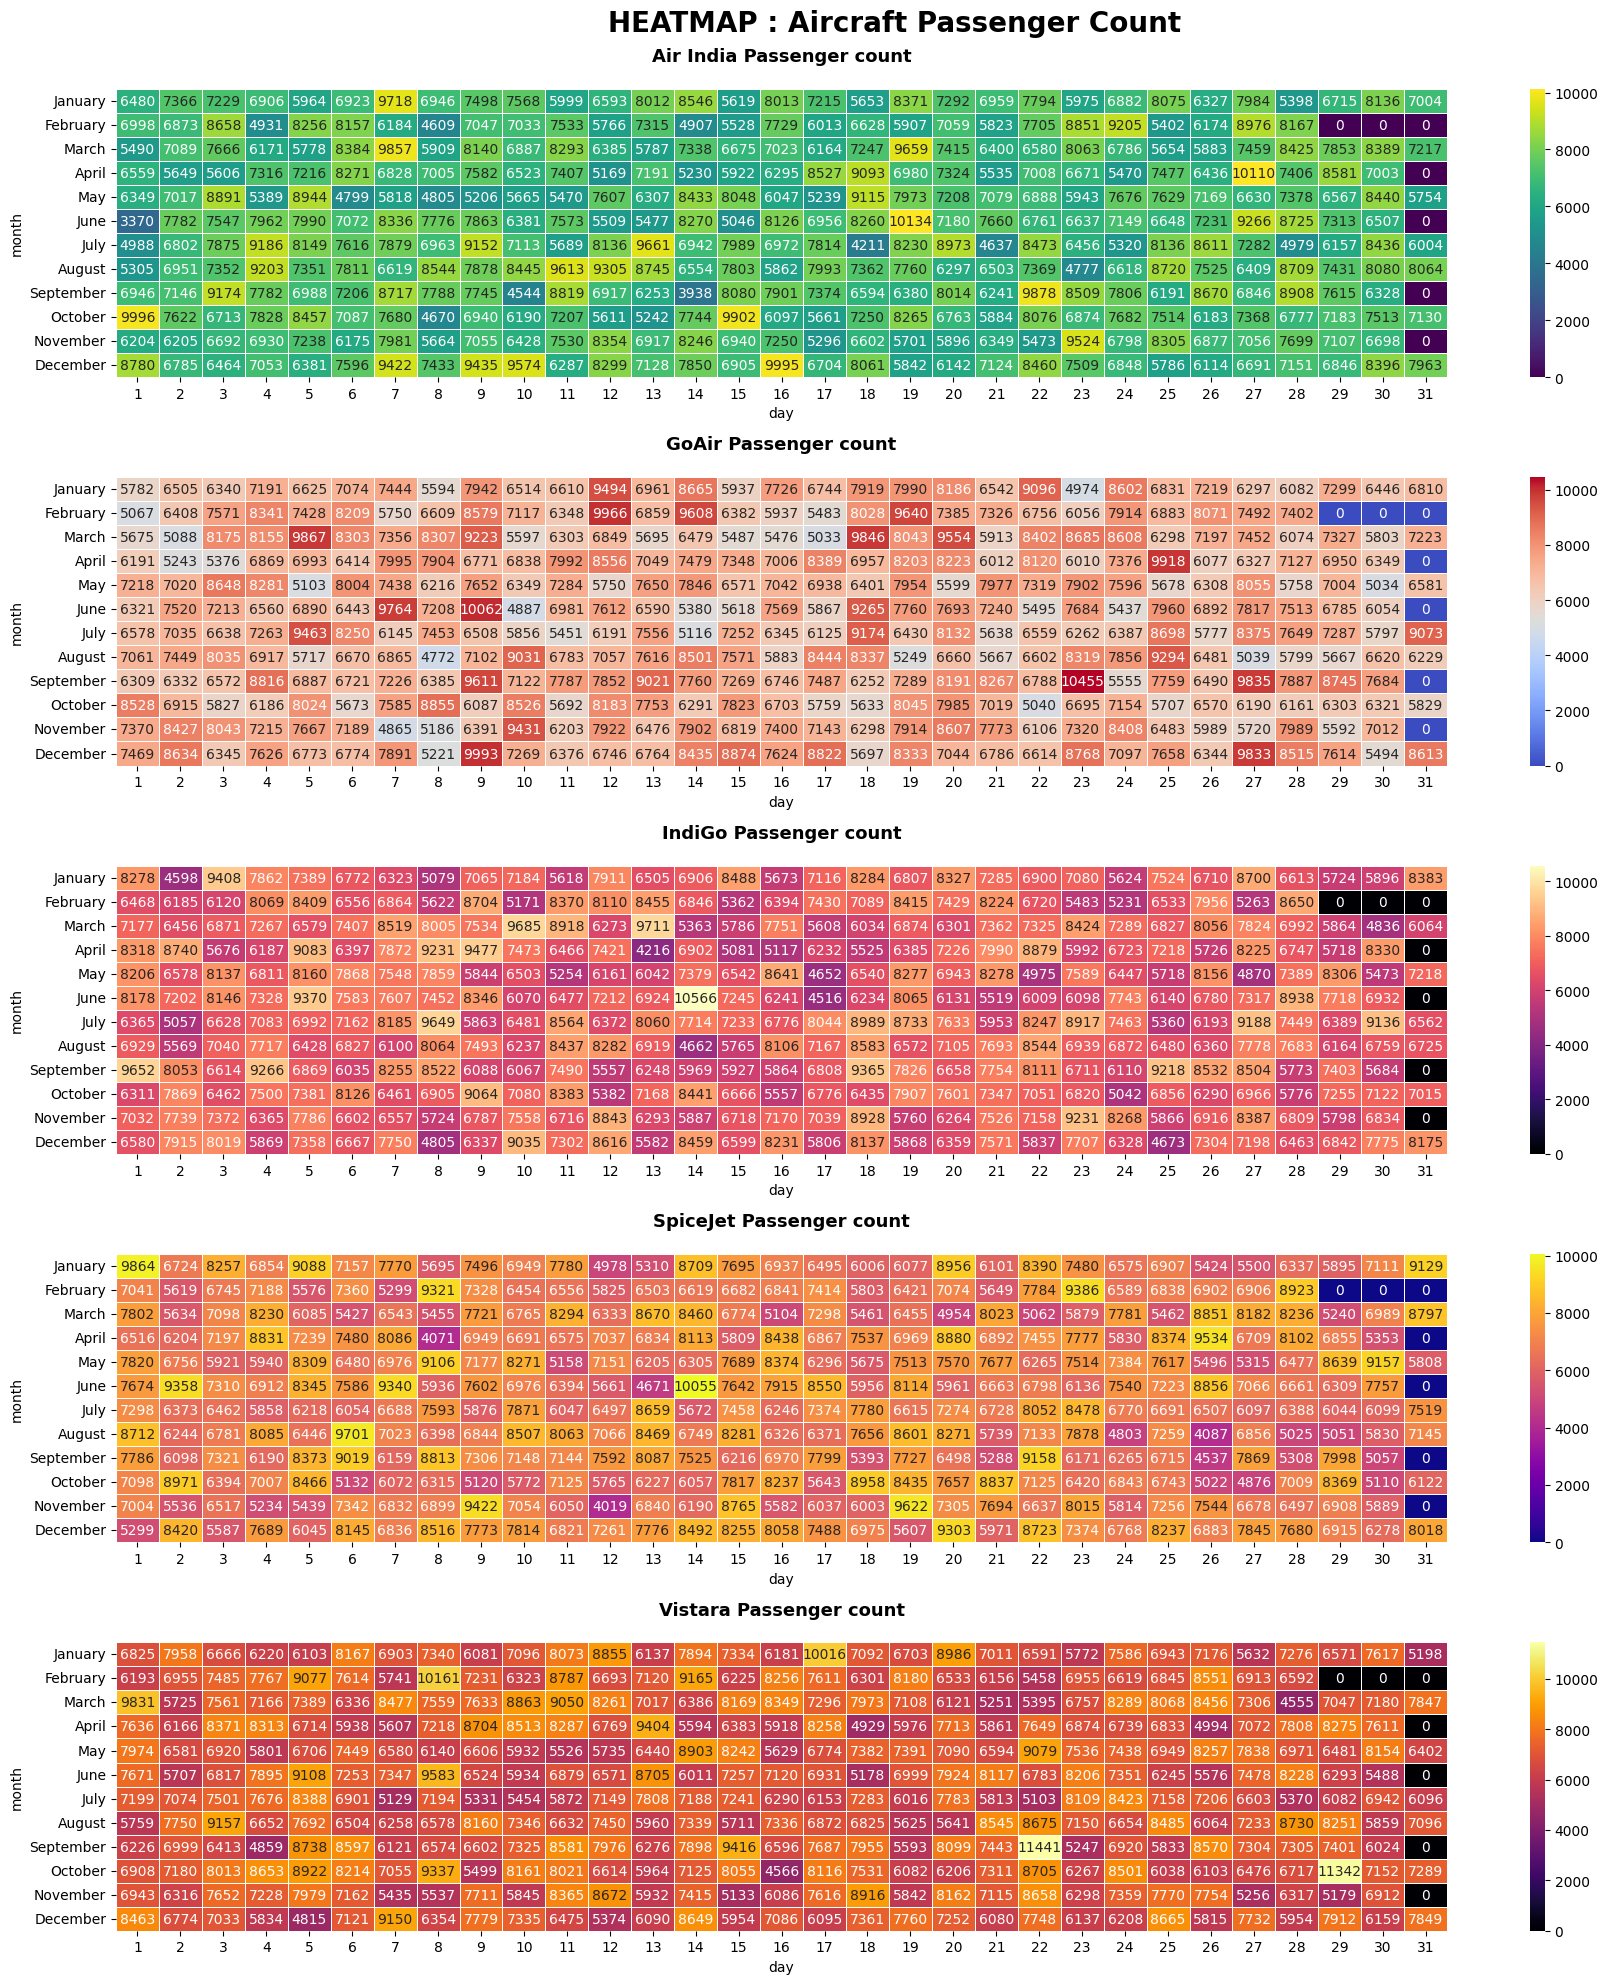

In [29]:
air=ADPC["Airline"].unique()
fig,axes=plt.subplots(len(air),1,figsize=(18,20))
clrmap=["viridis","coolwarm","magma","plasma","inferno"]
for i,airline in enumerate(air):
    axs=axes[i]
    sub=ADPC[ADPC["Airline"]==airline].drop("Airline",axis=1).set_index("month")
    sns.heatmap(sub,annot=True,fmt="d",ax=axs,cmap=clrmap[i],linecolor="white",linewidth=0.5)
    axs.set_title(f"{airline} Passenger count",fontsize=13,fontweight="bold",pad=20)
plt.suptitle("HEATMAP : Aircraft Passenger Count",fontsize=20,fontweight="bold",y=0.99)
plt.tight_layout()
plt.show()